<a href="https://colab.research.google.com/github/jamalinu/amazigh-nlp-spacy/blob/main/Tamazight_Social_Sentiment_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install spacy scikit-learn pandas matplotlib seaborn wordcloud -q
!python -m spacy download xx_ent_wiki_sm -q

print("✅ ¡Listo!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 61.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('xx_ent_wiki_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ ¡Listo!


In [2]:
import pandas as pd

data = {
    'texto': [
        # Positivos
        'Tamazight yelha, d tutlayt n yimaziɣen',
        'Nefraḥ fell-as, d lxir i tmurt-nneɣ',
        'Tafat tezga ɣef tmurt n yimaziɣen',
        # Negativos
        'Ur nessaram ara, aɣbel meqqren deg tmurt',
        'Ttmeggiḍ s wudem n tmurt, ur yelhi ara',
        'Tamaziɣt ur tettwasexdem ara, d ɛib',
        # Neutrales
        'Tamaziɣt d tutlayt n imaziɣen n Tamazɣa',
        'Agraw n tmaziɣt ad yili ass n sin',
        'Taddart-a tesɛa 500 n yimezdaɣ imaziɣen',
    ],
    'sentimiento': [
        'Positivo', 'Positivo', 'Positivo',
        'Negativo', 'Negativo', 'Negativo',
        'Neutral',  'Neutral',  'Neutral',
    ]
}

df = pd.DataFrame(data)
print(df)

                                      texto sentimiento
0    Tamazight yelha, d tutlayt n yimaziɣen    Positivo
1       Nefraḥ fell-as, d lxir i tmurt-nneɣ    Positivo
2         Tafat tezga ɣef tmurt n yimaziɣen    Positivo
3  Ur nessaram ara, aɣbel meqqren deg tmurt    Negativo
4    Ttmeggiḍ s wudem n tmurt, ur yelhi ara    Negativo
5       Tamaziɣt ur tettwasexdem ara, d ɛib    Negativo
6   Tamaziɣt d tutlayt n imaziɣen n Tamazɣa     Neutral
7         Agraw n tmaziɣt ad yili ass n sin     Neutral
8   Taddart-a tesɛa 500 n yimezdaɣ imaziɣen     Neutral


In [3]:
import spacy

# Cargar el modelo multilingüe
nlp = spacy.load('xx_ent_wiki_sm')

# Palabras vacías en Tamazight (no aportan significado)
STOPWORDS = {'d', 'n', 'i', 'a', 'ad', 'ur', 'ara', 'deg', 'ɣef', 's'}

def limpiar_texto(texto):
    doc = nlp(texto.lower())
    tokens = [token.text for token in doc
              if not token.is_punct
              and token.text not in STOPWORDS
              and len(token.text) > 1]
    return ' '.join(tokens)

# Aplicar al dataset
df['texto_limpio'] = df['texto'].apply(limpiar_texto)
print(df[['texto', 'texto_limpio']])

                                      texto  \
0    Tamazight yelha, d tutlayt n yimaziɣen   
1       Nefraḥ fell-as, d lxir i tmurt-nneɣ   
2         Tafat tezga ɣef tmurt n yimaziɣen   
3  Ur nessaram ara, aɣbel meqqren deg tmurt   
4    Ttmeggiḍ s wudem n tmurt, ur yelhi ara   
5       Tamaziɣt ur tettwasexdem ara, d ɛib   
6   Tamaziɣt d tutlayt n imaziɣen n Tamazɣa   
7         Agraw n tmaziɣt ad yili ass n sin   
8   Taddart-a tesɛa 500 n yimezdaɣ imaziɣen   

                          texto_limpio  
0    tamazight yelha tutlayt yimaziɣen  
1       nefraḥ fell as lxir tmurt nneɣ  
2          tafat tezga tmurt yimaziɣen  
3         nessaram aɣbel meqqren tmurt  
4           ttmeggiḍ wudem tmurt yelhi  
5            tamaziɣt tettwasexdem ɛib  
6    tamaziɣt tutlayt imaziɣen tamazɣa  
7           agraw tmaziɣt yili ass sin  
8  taddart tesɛa 500 yimezdaɣ imaziɣen  


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Separar texto y etiquetas
X = df['texto_limpio']
y = df['sentimiento']

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Convertir texto a números (TF-IDF)
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

# 4. Entrenar el modelo
modelo = LogisticRegression()
modelo.fit(X_train_vec, y_train)

# 5. Evaluar
y_pred = modelo.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negativo       0.00      0.00      0.00       1.0
     Neutral       0.00      0.00      0.00       1.0
    Positivo       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
def predecir(texto):
    texto_limpio = limpiar_texto(texto)
    texto_vec = vectorizer.transform([texto_limpio])
    resultado = modelo.predict(texto_vec)[0]
    print(f"Texto:      {texto}")
    print(f"Sentimiento: {resultado}")

# Prueba con estos ejemplos
predecir('Tamazight yelha, nefraḥ fell-as')
predecir('Ur nessaram ara, aɣbel meqqren')
predecir('Agraw n tmaziɣt ad yili deg taddart')
predecir('Amddukel n uma ysbeh')

Texto:      Tamazight yelha, nefraḥ fell-as
Sentimiento: Positivo
Texto:      Ur nessaram ara, aɣbel meqqren
Sentimiento: Negativo
Texto:      Agraw n tmaziɣt ad yili deg taddart
Sentimiento: Neutral
Texto:      Amddukel n uma ysbeh
Sentimiento: Negativo


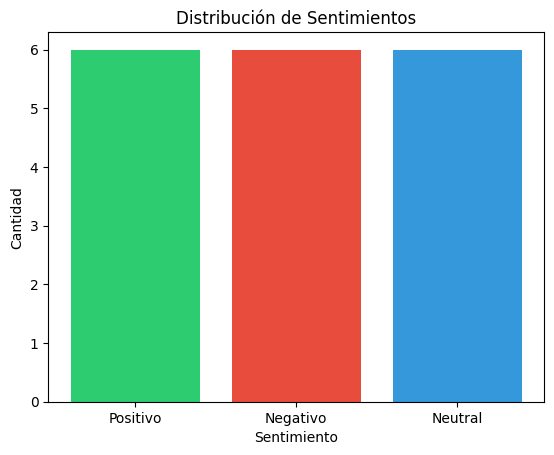

In [13]:
import matplotlib.pyplot as plt

# Contar cada sentimiento
conteo = df['sentimiento'].value_counts()

# Gráfico de barras
colores = ['#2ecc71', '#e74c3c', '#3498db']

plt.bar(conteo.index, conteo.values, color=colores)
plt.title('Distribución de Sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad')
plt.show()

In [12]:
data = {
    'texto': [
        # Positivos
        'Tamazight yelha, d tutlayt n yimaziɣen',
        'Nefraḥ fell-as, d lxir i tmurt-nneɣ',
        'Tafat tezga ɣef tmurt n yimaziɣen',
        'Azul! nefraḥ meqqren ass-a',
        'Yelha wayen i d-nefka i tmurt',
        'Tmusni n tamaziɣt d tizeɣt i lxir',
        # Negativos
        'Ur nessaram ara, aɣbel meqqren deg tmurt',
        'Ttmeggiḍ s wudem n tmurt, ur yelhi ara',
        'Tamaziɣt ur tettwasexdem ara, d ɛib',
        'Ur ufiɣ ara ccɣel, ur yelhi wayen akk',
        'Aɣbel meqqren, nettḥazen fell-as',
        'Lxsara meqqren i tmurt-nneɣ',
        # Neutrales
        'Tamaziɣt d tutlayt n imaziɣen n Tamazɣa',
        'Agraw n tmaziɣt ad yili ass n sin',
        'Taddart-a tesɛa 500 n yimezdaɣ imaziɣen',
        'Asentel n tira n tamaziɣt yettwasexdem',
        'Imezdaɣ n tmurt qqnen s tɣiwant',
        'Aseggas-a tamaziɣt tettwasexdem deg uɣmis',
    ],
    'sentimiento': [
        'Positivo', 'Positivo', 'Positivo',
        'Positivo', 'Positivo', 'Positivo',
        'Negativo', 'Negativo', 'Negativo',
        'Negativo', 'Negativo', 'Negativo',
        'Neutral',  'Neutral',  'Neutral',
        'Neutral',  'Neutral',  'Neutral',
    ]
}

df = pd.DataFrame(data)
print(f'Total: {len(df)} ejemplos')

Total: 18 ejemplos


In [14]:
import spacy

# Cargar el modelo multilingüe
nlp = spacy.load('xx_ent_wiki_sm')

# Palabras vacías en Tamazight (no aportan significado)
STOPWORDS = {'d', 'n', 'i', 'a', 'ad', 'ur', 'ara', 'deg', 'ɣef', 's'}

def limpiar_texto(texto):
    doc = nlp(texto.lower())
    tokens = [token.text for token in doc
              if not token.is_punct
              and token.text not in STOPWORDS
              and len(token.text) > 1]
    return ' '.join(tokens)

# Aplicar al dataset
df['texto_limpio'] = df['texto'].apply(limpiar_texto)
print(df[['texto', 'texto_limpio']])

                                        texto  \
0      Tamazight yelha, d tutlayt n yimaziɣen   
1         Nefraḥ fell-as, d lxir i tmurt-nneɣ   
2           Tafat tezga ɣef tmurt n yimaziɣen   
3                  Azul! nefraḥ meqqren ass-a   
4               Yelha wayen i d-nefka i tmurt   
5           Tmusni n tamaziɣt d tizeɣt i lxir   
6    Ur nessaram ara, aɣbel meqqren deg tmurt   
7      Ttmeggiḍ s wudem n tmurt, ur yelhi ara   
8         Tamaziɣt ur tettwasexdem ara, d ɛib   
9       Ur ufiɣ ara ccɣel, ur yelhi wayen akk   
10           Aɣbel meqqren, nettḥazen fell-as   
11                Lxsara meqqren i tmurt-nneɣ   
12    Tamaziɣt d tutlayt n imaziɣen n Tamazɣa   
13          Agraw n tmaziɣt ad yili ass n sin   
14    Taddart-a tesɛa 500 n yimezdaɣ imaziɣen   
15     Asentel n tira n tamaziɣt yettwasexdem   
16            Imezdaɣ n tmurt qqnen s tɣiwant   
17  Aseggas-a tamaziɣt tettwasexdem deg uɣmis   

                           texto_limpio  
0     tamazight yelha tutl

In [15]:
datos_nuevos = {
    'texto': [
        # Positivos
        'Tamazight tezmer ad tili d tutlayt taɣelnawt',
        'Nessen tamaziɣt, nessen imɣan-nneɣ',
        'Tarwa-nneɣ ssnen tamaziɣt, d lxir i zdat',
        'Imaziɣen d imezdaɣ n wemmaɣ, yelha',
        # Negativos
        'Ur nwi ara tafat, kulci yesɛa aɣbel',
        'Imeɣnasen ur sɛin ara ccɣel, d aɣbel',
        'Tutlayt-nneɣ tettmuqel ɣer deffir, nettḥazen',
        'Ul-iw yebɛed s wayen yuɣen tmurt-nneɣ',
        # Neutrales
        'Tifinagh d tira n tutlayt tamaziɣt',
        'Aseggas-a 2024 tamaziɣt tettwasexdem deg uɣmis',
        'Tesdawit tesɛa agejdan n tutlayt tamaziɣt',
        'Imezdaɣ ttmeslayen tamaziɣt d taɛrabt',
    ],
    'sentimiento': [
        'Positivo', 'Positivo', 'Positivo', 'Positivo',
        'Negativo', 'Negativo', 'Negativo', 'Negativo',
        'Neutral',  'Neutral',  'Neutral',  'Neutral',
    ]
}

df_nuevo = pd.DataFrame(datos_nuevos)
df = pd.concat([df, df_nuevo], ignore_index=True)
print(f'✅ Total de ejemplos ahora: {len(df)}')
print(df['sentimiento'].value_counts())

✅ Total de ejemplos ahora: 30
sentimiento
Positivo    10
Negativo    10
Neutral     10
Name: count, dtype: int64


In [16]:
# Léxico de sentimientos en Tamazight
LEXICO = {
    # Positivos
    'yelha': +2, 'lxir': +2, 'nefraḥ': +2,
    'tafat': +2, 'tizeɣt': +2, 'freḥ': +2,
    'yelhan': +2, 'azul': +1, 'tezmer': +1,
    # Negativos
    'aɣbel': -2, 'ccan': -2, 'nettḥazen': -2,
    'lxsara': -2, 'ɛib': -2, 'deffir': -1,
    'yebɛed': -1, 'meẓẓi': -1,
}

def limpiar_texto_v2(texto):
    doc = nlp(texto.lower())
    tokens = [token.text for token in doc
              if not token.is_punct
              and token.text not in STOPWORDS
              and len(token.text) > 1]
    return ' '.join(tokens)

def score_lexico(texto):
    palabras = texto.lower().split()
    return sum(LEXICO.get(p, 0) for p in palabras)

# Aplicar al dataset
df['texto_limpio'] = df['texto'].apply(limpiar_texto_v2)
df['score']        = df['texto_limpio'].apply(score_lexico)

print(df[['sentimiento', 'texto_limpio', 'score']].head(9))

  sentimiento                       texto_limpio  score
0    Positivo  tamazight yelha tutlayt yimaziɣen      2
1    Positivo     nefraḥ fell as lxir tmurt nneɣ      4
2    Positivo        tafat tezga tmurt yimaziɣen      2
3    Positivo            azul nefraḥ meqqren ass      3
4    Positivo            yelha wayen nefka tmurt      2
5    Positivo        tmusni tamaziɣt tizeɣt lxir      4
6    Negativo       nessaram aɣbel meqqren tmurt     -2
7    Negativo         ttmeggiḍ wudem tmurt yelhi      0
8    Negativo          tamaziɣt tettwasexdem ɛib     -2


In [17]:
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df['texto_limpio']
y = df['sentimiento']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

modelos = {
    'Regresión Logística': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2))),
        ('clf',   LogisticRegression(max_iter=1000))
    ]),
    'SVM': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2))),
        ('clf',   SVC(kernel='linear', probability=True))
    ]),
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf',   MultinomialNB())
    ]),
}

print('Modelo               | Accuracy')
print('─' * 35)
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    acc = accuracy_score(y_test, modelo.predict(X_test))
    print(f'{nombre:<20} | {acc*100:.1f}%')

Modelo               | Accuracy
───────────────────────────────────
Regresión Logística  | 66.7%
SVM                  | 66.7%
Naive Bayes          | 77.8%


In [18]:
import joblib

# Guardar el mejor modelo
mejor_modelo = modelos['Naive Bayes']
joblib.dump(mejor_modelo, 'modelo_tamazight.pkl')
joblib.dump(vectorizer,   'vectorizer_tamazight.pkl')

print('✅ Modelo guardado: modelo_tamazight.pkl')

✅ Modelo guardado: modelo_tamazight.pkl


In [19]:
# Cargar el modelo guardado
modelo_cargado = joblib.load('modelo_tamazight.pkl')
print('✅ Modelo cargado listo para usar!')

✅ Modelo cargado listo para usar!
